In [88]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
    
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import PowerTransformer


In [89]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [90]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]

In [91]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [92]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [93]:
(MAASTRO_D1['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [94]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [95]:
# need to choose patient_id from MAASTRO_D1 in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [96]:
# Merge MAASTRO_D1 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [97]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [98]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [99]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [100]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [101]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 14)
y_train:  (139,)


In [102]:
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)

In [103]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]
lower, upper = np.percentile(y_MAASTRO['OS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 16)

# Feature Selection with Random Forest

In [104]:
# Setting y 
y_rsf_classifier = clinical_train['event_OS']

# Define parameters for StratifiedKFold
n_splits = 5
n_repeats = 4

# Initialize variables to store results
all_feature_importances = []

# Perform stratified 5-split 4 times and train Random Forest Classifier for each split
for i in range(n_repeats):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=i)  # Use different random_state for each repeat
    repeat_feature_importances = []
    
    for train_index, test_index in skf.split(X, y_rsf_classifier):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y_rsf_classifier.iloc[train_index], y_rsf_classifier.iloc[test_index]

        # Train Random Forest Classifier
        rf_classifier = RandomForestClassifier(random_state=i)  # You can adjust parameters as needed
        rf_classifier.fit(X_train, y_train)

        # Store feature importances
        repeat_feature_importances.append(rf_classifier.feature_importances_)

    all_feature_importances.append(repeat_feature_importances)

# Convert to numpy array for easier manipulation
all_feature_importances = np.array(all_feature_importances)

# Sum feature importances across repeats and folds
sum_feature_importances = np.sum(all_feature_importances, axis=(0, 1))

# Get feature names
feature_names = list(X)

# Create a DataFrame
df_feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance_Sum': sum_feature_importances})

# Sort feature importances by their sum
df_feature_importances_sorted = df_feature_importances.sort_values(by='Importance_Sum', ascending=False)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

RandomForestClassifier(random_state=0)

...

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

RandomForestClassifier(random_state=3)

<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using Random Forest Classifier')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

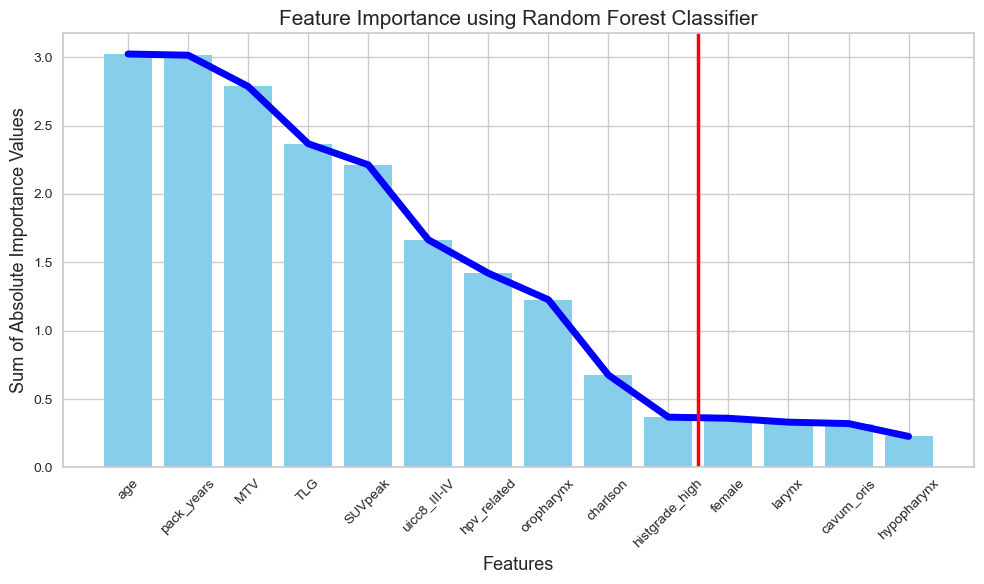

In [106]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(df_feature_importances_sorted['Feature'], 
        df_feature_importances_sorted['Importance_Sum'], 
        color='skyblue')
plt.plot(df_feature_importances_sorted['Feature'], 
         df_feature_importances_sorted['Importance_Sum'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using Random Forest Classifier', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=9.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [107]:
selected_features = df_feature_importances_sorted['Feature'][0:10]

In [108]:
X_rf = X[selected_features]
X_new = X_rf.copy() 

X_MAASTRO_rf = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_rf.copy()

# Yeo-Johnson Transformation

In [109]:
original_X = X.copy()

In [110]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [111]:
X_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,54.238356,0.000000,7.934,86.228420,14.473272,0.0,0.0,1,0,1
1,54.539726,27.404795,1.656,7.040100,5.044678,0.0,0.0,0,1,0
2,59.019178,41.019178,14.502,83.569669,7.839043,1.0,0.0,0,1,1
3,70.726027,37.500000,2.440,5.567091,2.880631,0.0,0.0,0,1,0
4,67.865753,53.000000,3.668,16.150550,5.402006,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,60.435616,0.000000,3.650,26.280140,9.290139,0.0,1.0,1,0,1
135,68.794521,0.000000,18.967,101.754834,7.172883,1.0,1.0,1,0,1
136,57.498630,39.498630,6.370,66.273201,13.873187,0.0,1.0,1,1,1
137,65.684932,71.527397,12.443,71.832443,7.507419,1.0,1.0,1,1,1


In [112]:
X_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.785036,-1.533345,0.080033,0.343545,0.750782,0.0,0.0,1,0,1
1,-0.746998,0.397233,-1.722060,-1.657833,-1.213660,0.0,0.0,0,1,0
2,-0.175256,0.830437,0.735716,0.318631,-0.474112,1.0,0.0,0,1,1
3,1.371631,0.727938,-1.291020,-1.835650,-1.992620,0.0,0.0,0,1,0
4,0.987008,1.144253,-0.816679,-1.003396,-1.106304,0.0,0.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
134,0.007949,-1.533345,-0.822461,-0.611074,-0.158214,0.0,1.0,1,0,1
135,1.111443,-1.533345,1.008070,0.474941,-0.632361,1.0,1.0,1,0,1
136,-0.370651,0.786825,-0.170908,0.133612,0.658564,0.0,1.0,1,1,1
137,0.696583,1.554125,0.574668,0.197985,-0.551725,1.0,1.0,1,1,1


In [113]:
MAASTRO_new

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,55,0,22.841,263.611623,15.438583,0,1,1,1,1
1,55,20,5.660,36.980700,8.829353,1,0,1,0,0
2,55,6,7.791,74.636342,13.476123,1,0,1,1,0
3,61,45,7.908,46.791979,8.632732,1,0,0,1,1
4,70,59,15.237,107.637514,9.783954,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,66,55,6.110,144.490782,31.338410,1,0,0,0,0
95,63,174,7.182,69.214868,13.041604,1,0,0,1,0
96,63,0,16.483,102.594274,8.944517,1,1,1,1,1
97,54,0,9.981,103.229492,14.184236,0,1,1,0,1


In [114]:
MAASTRO_new_std

,age,pack_years,MTV,TLG,SUVpeak,uicc8_III-IV,hpv_related,oropharynx,charlson,histgrade_high
0,-0.688798,-1.533345,1.188930,1.218887,0.893634,0,1,1,1,1
1,-0.688798,0.104884,-0.307894,-0.335276,-0.254678,1,0,1,0,0
2,-0.688798,-0.713198,0.059450,0.228548,0.595996,1,0,1,1,0
3,0.081262,0.940197,0.076321,-0.145668,-0.296877,1,0,0,1,1
4,1.273609,1.285347,0.786849,0.519421,-0.058378,0,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
94,0.738387,1.192311,-0.219083,0.751363,2.645651,1,0,0,0,0
95,0.342484,3.094727,-0.033134,0.168333,0.526028,1,0,0,1,0
96,0.342484,-1.533345,0.867254,0.481447,-0.230255,1,1,1,1,1
97,-0.815082,-1.533345,0.336049,0.486335,0.706707,0,1,1,0,1


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [115]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:00:38,499] A new study created in memory with name: no-name-9a41244a-3fba-43e6-829d-b32cb556ec98


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7359307359307359
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8143459915611815


[I 2024-04-14 00:00:42,656] A new study created in memory with name: no-name-19ac64aa-26ef-490e-82f5-b8144df3557c


Fold 5 C-index: 0.6525821596244131
[I 2024-04-14 00:00:42,629] Trial 0 finished with value: 0.7521614132776079 and parameters: {}. Best is trial 0 with value: 0.7521614132776079.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7521614132776079], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 39, 299091), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 42, 587513), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7521614132776079


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17366248946918472
Fold 2 IBS: 0.19749826123153413
Fold 3 IBS: 0.1571567672235763
Fold 4 IBS: 0.14720875153738255
Fold 5 IBS: 0.26939998327193043
[I 2024-04-14 00:00:45,676] Trial 0 finished with value: 0.18898525054672163 and parameters: {}. Best is trial 0 with value: 0.18898525054672163.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18898525054672163], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 42, 910334), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 45, 675878), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18898525054672163


In [116]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [117]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.752
train_ibs:  0.189


#### Test

In [118]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [119]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.599
IBS score: 0.288


In [120]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [121]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [122]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:00:46,221] A new study created in memory with name: no-name-0e8ab956-5e83-4b5f-b778-7e7cc5952241


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6298701298701299
Fold 2 C-index: 0.640625
Fold 3 C-index: 0.7524509803921569
Fold 4 C-index: 0.7784810126582279


[I 2024-04-14 00:00:48,427] A new study created in memory with name: no-name-c1644d7c-1b70-41c6-a684-09fe90edfa0e


Fold 5 C-index: 0.5727699530516432
[I 2024-04-14 00:00:48,417] Trial 0 finished with value: 0.6748394151944316 and parameters: {}. Best is trial 0 with value: 0.6748394151944316.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6748394151944316], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 46, 462768), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 48, 417294), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6748394151944316


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.21397651730092662
Fold 2 IBS: 0.22157791055888598
Fold 3 IBS: 0.20453594148397225
Fold 4 IBS: 0.22473803361997696
Fold 5 IBS: 0.21812431365411103
[I 2024-04-14 00:00:50,599] Trial 0 finished with value: 0.21659054332357458 and parameters: {}. Best is trial 0 with value: 0.21659054332357458.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21659054332357458], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 48, 710631), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 50, 598773), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21659054332357458


In [123]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [124]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.675
train_ibs:  0.217


#### Test

In [125]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [126]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.534


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.221


In [127]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [128]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:00:51,959] A new study created in memory with name: no-name-39f8ec66-cc13-41fb-b960-94806e1f3b39


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.7990196078431373
Fold 4 C-index: 0.8227848101265823


[I 2024-04-14 00:00:54,791] A new study created in memory with name: no-name-bf50d5b7-77d7-42bf-9dcd-cabfa6e584ce


Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:00:54,777] Trial 0 finished with value: 0.7574857692716465 and parameters: {}. Best is trial 0 with value: 0.7574857692716465.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7574857692716465], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 52, 135350), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 54, 777250), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7574857692716465


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.17394106981695928
Fold 2 IBS: 0.1968225895586345
Fold 3 IBS: 0.15634647161308146
Fold 4 IBS: 0.14293719545549805
Fold 5 IBS: 0.2670666306250002
[I 2024-04-14 00:00:58,493] Trial 0 finished with value: 0.18742279141383472 and parameters: {}. Best is trial 0 with value: 0.18742279141383472.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18742279141383472], datetime_start=datetime.datetime(2024, 4, 14, 0, 0, 55, 116657), datetime_complete=datetime.datetime(2024, 4, 14, 0, 0, 58, 493088), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18742279141383472


In [129]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [130]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.757
train_ibs:  0.187


#### Test

In [131]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [132]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.601


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.287


In [133]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [134]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:01:00,501] A new study created in memory with name: no-name-5f2c4f0c-2d70-45f6-8016-3070ecba3e4c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:01:03,275] Trial 0 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:01:07,718] Trial 1 finished with value: 0.7575733042856521 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7589285714285714
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8185654008438819
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:01:10,913] Trial 2 finished with value: 0.756729422429112 and parameters: {'l1_ratio': 0.22692876841884668}. Bes

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:02:15,587] Trial 24 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.7602371709740536}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:02:18,287] Trial 25 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.891573855041803}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:02:20,978] Trial 26 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.4514399534035586}. Be

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:03:24,373] Trial 48 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.5033132688848968}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:03:27,387] Trial 49 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.355745098499332}. Best is trial 0 with value: 0.7584661614285092.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7633928571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8227848101265823
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:03:29,799] Trial 50 finished with value: 0.7584661614285092 and parameters: {'l1_ratio': 0.8449632453631055}. Be

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.17408474580580693
Fold 2 IBS: 0.19709813075377364
Fold 3 IBS: 0.156072204774046
Fold 4 IBS: 0.14296360202347858
Fold 5 IBS: 0.26674478013511227
[I 2024-04-14 00:05:26,686] Trial 0 finished with value: 0.18739269269844347 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.18739269269844347.
Fold 1 IBS: 0.1742913793067185
Fold 2 IBS: 0.1976004676326488
Fold 3 IBS: 0.1557367685803215
Fold 4 IBS: 0.14322724863641717
Fold 5 IBS: 0.26791958476864486
[I 2024-04-14 00:05:29,048] Trial 1 finished with value: 0.18775508978495017 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.18739269269844347.
Fold 1 IBS: 0.17434350816200053
Fold 2 IBS: 0.19780587256136875
Fold 3 IBS: 0.15565140820843112
Fold 4 IBS: 0.14363923386813268
Fold 5 IBS: 0.2678346186915313
[I 2024-04-14 00:05:31,621] Trial 2 finished with value: 0.18785492829829287 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.187392692698443

Fold 1 IBS: 0.17400275499856457
Fold 2 IBS: 0.19682515183446941
Fold 3 IBS: 0.15621394817927417
Fold 4 IBS: 0.1429662927241399
Fold 5 IBS: 0.2668951983549757
[I 2024-04-14 00:06:27,493] Trial 25 finished with value: 0.18738066921828475 and parameters: {'l1_ratio': 0.8965991900133715}. Best is trial 17 with value: 0.18736476617692194.
Fold 1 IBS: 0.17411538091988202
Fold 2 IBS: 0.19711142608611557
Fold 3 IBS: 0.15600358910101614
Fold 4 IBS: 0.14289540858424318
Fold 5 IBS: 0.2668065052647486
[I 2024-04-14 00:06:29,881] Trial 26 finished with value: 0.1873864619912011 and parameters: {'l1_ratio': 0.6634649065815911}. Best is trial 17 with value: 0.18736476617692194.
Fold 1 IBS: 0.17417972871606774
Fold 2 IBS: 0.19731439546993246
Fold 3 IBS: 0.15589678312036856
Fold 4 IBS: 0.14306697696545473
Fold 5 IBS: 0.2668062604738544
[I 2024-04-14 00:06:32,625] Trial 27 finished with value: 0.18745282894913556 and parameters: {'l1_ratio': 0.526404719543659}. Best is trial 17 with value: 0.18736476617

Fold 1 IBS: 0.17401284213180115
Fold 2 IBS: 0.19682481728919132
Fold 3 IBS: 0.156269264636447
Fold 4 IBS: 0.14294366514569254
Fold 5 IBS: 0.26684099071976325
[I 2024-04-14 00:07:28,822] Trial 50 finished with value: 0.18737831598457905 and parameters: {'l1_ratio': 0.881590524348896}. Best is trial 31 with value: 0.18735362216707488.
Fold 1 IBS: 0.1740312034902959
Fold 2 IBS: 0.19697129084927148
Fold 3 IBS: 0.1561698059263587
Fold 4 IBS: 0.14299741366266247
Fold 5 IBS: 0.2669671316915048
[I 2024-04-14 00:07:30,898] Trial 51 finished with value: 0.1874273691240187 and parameters: {'l1_ratio': 0.8079441921789657}. Best is trial 31 with value: 0.18735362216707488.
Fold 1 IBS: 0.17400604301315117
Fold 2 IBS: 0.19683124714547437
Fold 3 IBS: 0.1562172374086706
Fold 4 IBS: 0.14288458334648887
Fold 5 IBS: 0.26690348372353284
[I 2024-04-14 00:07:33,025] Trial 52 finished with value: 0.1873685189274636 and parameters: {'l1_ratio': 0.8435532069584513}. Best is trial 31 with value: 0.18735362216707

Fold 1 IBS: 0.1740476809372503
Fold 2 IBS: 0.1969768190956444
Fold 3 IBS: 0.156135251414501
Fold 4 IBS: 0.1429603075631841
Fold 5 IBS: 0.26689109583053616
[I 2024-04-14 00:08:26,836] Trial 75 finished with value: 0.1874022309682232 and parameters: {'l1_ratio': 0.7860927241572034}. Best is trial 73 with value: 0.18734948875252558.
Fold 1 IBS: 0.17401796212847712
Fold 2 IBS: 0.19683037360233016
Fold 3 IBS: 0.1561922826996747
Fold 4 IBS: 0.14285495903731452
Fold 5 IBS: 0.266845150330133
[I 2024-04-14 00:08:29,091] Trial 76 finished with value: 0.1873481455595859 and parameters: {'l1_ratio': 0.8263306439323242}. Best is trial 76 with value: 0.1873481455595859.
Fold 1 IBS: 0.17406607307024544
Fold 2 IBS: 0.19698468496067068
Fold 3 IBS: 0.15611138465912425
Fold 4 IBS: 0.14300580346267408
Fold 5 IBS: 0.26683099836378205
[I 2024-04-14 00:08:31,814] Trial 77 finished with value: 0.1873997889032993 and parameters: {'l1_ratio': 0.7181610975319183}. Best is trial 76 with value: 0.1873481455595859.

In [135]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [136]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.758
train_ibs:  0.187


#### Test

In [137]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [138]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.602


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.7465707208188301)

test_ibs:  0.287


In [139]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [140]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 00:09:25,367] A new study created in memory with name: no-name-c76f3c92-e569-4aaa-b2f3-7074e09cc33c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8544303797468354
Fold 5 C-index: 0.636150234741784
[I 2024-04-14 00:09:39,529] Trial 0 finished with value: 0.7363355015582791 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.7363355015582791.
Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.6696428571428571
Fold 3 C-index: 0.803921568627451
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.647887323943662
[I 2024-04-14 00:09:50,128] Trial 1 finished with value: 0.7384774286868347 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'max

Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:32:02,710] Trial 15 finished with value: 0.7926763351493695 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 2, 'min_samples_leaf': 16, 'max_depth': 1, 'n_estimators': 483, 'oob_score': True, 'max_samples': 0.9915936271771615, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.08807762154599924, 'warm_start': True}. Best is trial 15 with value: 0.7926763351493695.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.8169642857142857
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:32:15,542] Trial 16 finished with value: 0.7970594520324864 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 2, 'min_samples_leaf': 18, 'max_depth': 1, 'n_estimators': 498, 'oob_score': True, 'max_samples': 0.9632019382250055, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.075649367762977

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8818565400843882
Fold 5 C-index: 0.7183098591549296
[I 2024-04-14 00:33:34,598] Trial 30 finished with value: 0.793378072310303 and parameters: {'min_samples_split': 6, 'max_leaf_nodes': 4, 'min_samples_leaf': 13, 'max_depth': 3, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.8295636627924149, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.03737500582975329, 'warm_start': True}. Best is trial 25 with value: 0.810205399401531.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8303571428571429
Fold 3 C-index: 0.8284313725490197
Fold 4 C-index: 0.8839662447257384
Fold 5 C-index: 0.7089201877934272
[I 2024-04-14 00:33:39,609] Trial 31 finished with value: 0.7957895350396111 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 8, 'min_samples_leaf': 17, 'max_depth': 7, 'n_estimators': 230, 'oob_score': True, 'max_samples': 0.8698146012029154, '

...

Fold 5 IBS: 0.22664902658714126
[I 2024-04-14 00:45:16,061] Trial 31 finished with value: 0.18664402376401593 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 293, 'oob_score': False, 'max_samples': 0.760076202384518, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.12053440019786568}. Best is trial 25 with value: 0.18541060533130255.
Fold 1 IBS: 0.17924391428026357
Fold 2 IBS: 0.21580555805224105
Fold 3 IBS: 0.16169962680759295
Fold 4 IBS: 0.1473771359605064
Fold 5 IBS: 0.22270811223488068
[I 2024-04-14 00:45:28,802] Trial 32 finished with value: 0.18536686946709696 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 18, 'n_estimators': 367, 'oob_score': False, 'max_samples': 0.6195244229601323, 'max_features': 'log2', 'min_weight_fraction_leaf': 0.10211517213176136}. Best is trial 32 with value: 0.18536686946709696.
Fold 1 IBS: 0.17986602186177758
Fold 2 IBS: 0.21

Fold 1 IBS: 0.17739465038110155
Fold 2 IBS: 0.21276243506490725
Fold 3 IBS: 0.16160555782186015
Fold 4 IBS: 0.14311242513123648
Fold 5 IBS: 0.22197207125200943
[I 2024-04-14 00:46:40,286] Trial 47 finished with value: 0.18336942793022298 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 11, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 91, 'oob_score': True, 'max_samples': 0.5030079701115354, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.06742576372903179}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17817455766126414
Fold 2 IBS: 0.2056142320761358
Fold 3 IBS: 0.17136980731682958
Fold 4 IBS: 0.1517629787282082
Fold 5 IBS: 0.2158509318926223
[I 2024-04-14 00:46:42,599] Trial 48 finished with value: 0.18455450153501202 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 5, 'n_estimators': 40, 'oob_score': True, 'max_samples': 0.45113067734816487, 'max_features': 'auto', 'min_weight_fraction_leaf

Fold 1 IBS: 0.18021371373261355
Fold 2 IBS: 0.20276408785346708
Fold 3 IBS: 0.1649417152136776
Fold 4 IBS: 0.15142221337436843
Fold 5 IBS: 0.21894260849421615
[I 2024-04-14 00:47:42,041] Trial 63 finished with value: 0.18365686773366857 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 4, 'min_samples_leaf': 10, 'max_depth': 6, 'n_estimators': 96, 'oob_score': True, 'max_samples': 0.595897376295266, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.012492189362659112}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17901142015584834
Fold 2 IBS: 0.21784040587874096
Fold 3 IBS: 0.16088565909392738
Fold 4 IBS: 0.14287077029960885
Fold 5 IBS: 0.22469333583962847
[I 2024-04-14 00:47:47,822] Trial 64 finished with value: 0.1850603182535508 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 6, 'min_samples_leaf': 7, 'max_depth': 9, 'n_estimators': 135, 'oob_score': True, 'max_samples': 0.6542957469639504, 'max_features': 'sqrt', 'min_weight_fraction_lea

Fold 1 IBS: 0.1846630295744542
Fold 2 IBS: 0.2094063233794573
Fold 3 IBS: 0.1725928631353916
Fold 4 IBS: 0.16850815329771193
Fold 5 IBS: 0.21861719205278374
[I 2024-04-14 00:48:58,997] Trial 79 finished with value: 0.19075751228795976 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 2, 'min_samples_leaf': 11, 'max_depth': 7, 'n_estimators': 85, 'oob_score': True, 'max_samples': 0.6691101514115952, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07379564215435265}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.1806562415271345
Fold 2 IBS: 0.2149229351576256
Fold 3 IBS: 0.1619331641155935
Fold 4 IBS: 0.1482603925846792
Fold 5 IBS: 0.22381820855608095
[I 2024-04-14 00:49:06,772] Trial 80 finished with value: 0.18591818838822274 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 6, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 193, 'oob_score': True, 'max_samples': 0.575453026455684, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.

Fold 1 IBS: 0.18067051892997218
Fold 2 IBS: 0.20976917694401034
Fold 3 IBS: 0.1627021515583648
Fold 4 IBS: 0.15155219149304505
Fold 5 IBS: 0.22007018815890209
[I 2024-04-14 00:50:04,045] Trial 95 finished with value: 0.1849528454168589 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 5, 'min_samples_leaf': 9, 'max_depth': 7, 'n_estimators': 132, 'oob_score': True, 'max_samples': 0.4847998384701818, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07698922447900798}. Best is trial 39 with value: 0.18152965851463443.
Fold 1 IBS: 0.17653837850706317
Fold 2 IBS: 0.21665820235713712
Fold 3 IBS: 0.15925978769855675
Fold 4 IBS: 0.1361996911640683
Fold 5 IBS: 0.22133644256987917
[I 2024-04-14 00:50:09,054] Trial 96 finished with value: 0.1819985004593409 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 9, 'n_estimators': 100, 'oob_score': True, 'max_samples': 0.6411081762780679, 'max_features': 'sqrt', 'min_weight_fraction_leaf'

In [141]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [142]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.867
train_ibs:  0.181


#### Test

In [143]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [144]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=13, max_leaf_nodes=12,
                     max_samples=0.8731189968319242, min_samples_leaf=2,
                     min_samples_split=7,
                     min_weight_fraction_leaf=0.012901666963593935,
                     n_estimators=393, random_state=123, warm_start=True)

test_cindex:  0.68


RandomSurvivalForest(max_depth=9, max_leaf_nodes=4,
                     max_samples=0.6434896963800851, min_samples_leaf=6,
                     min_samples_split=16,
                     min_weight_fraction_leaf=0.008689309516786857,
                     n_estimators=93, oob_score=True, random_state=123)

test_ibs:  0.204


In [145]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [146]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:50:27,950] A new study created in memory with name: no-name-93d0d7f3-ef92-4e6d-acdc-75288b52940b


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7186147186147186
Fold 2 C-index: 0.8035714285714286
Fold 3 C-index: 0.8431372549019608
Fold 4 C-index: 0.8523206751054853
Fold 5 C-index: 0.6948356807511737
[I 2024-04-14 00:50:30,581] Trial 0 finished with value: 0.7824959515889536 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7824959515889536.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:50:37,122] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8333333333333334
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6619718309859155
[I 2024-04-14 00:52:00,038] Trial 16 finished with value: 0.7674928647450487 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.7926307801682724.
Fold 1 C-index: 0.7727272727272727
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8161764705882353
Fold 4 C-index: 0.8164556962025317
Fold 5 C-index: 0.6384976525821596
[I 2024-04-14 00:52:03,202] Trial 17 finished with value: 0.7659142755628969 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.7316017316017316
Fold 2 C-index: 0.8348214285714286
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.7089201877934272
[I 2024-04-14 00:53:01,009] Trial 31 finished with value: 0.797945313921935 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 467, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.9286371142434082, 'min_weight_fraction_leaf': 0.043457520259011145}. Best is trial 31 with value: 0.797945313921935.
Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.8392857142857143
Fold 3 C-index: 0.8578431372549019
Fold 4 C-index: 0.8481012658227848
Fold 5 C-index: 0.704225352112676
[I 2024-04-14 00:53:04,918] Trial 32 finished with value: 0.7953456393497609 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 412, 'oob_score': False, 'warm_start': True, 'max_feature

...

Fold 1 IBS: 0.1700519965855827
Fold 2 IBS: 0.21054009443018218
Fold 3 IBS: 0.16719925029759086
Fold 4 IBS: 0.1613089358324982
Fold 5 IBS: 0.23161013296531519
[I 2024-04-14 01:02:00,466] Trial 30 finished with value: 0.18814208202223381 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 8, 'max_depth': 12, 'n_estimators': 231, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.5014558998220808, 'min_weight_fraction_leaf': 0.07553984363425942}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.17216923621723923
Fold 2 IBS: 0.2108044066276367
Fold 3 IBS: 0.16702564967756997
Fold 4 IBS: 0.16193700192755658
Fold 5 IBS: 0.22777679864148306
[I 2024-04-14 01:02:04,355] Trial 31 finished with value: 0.18794261861829709 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 8, 'min_samples_leaf': 9, 'max_depth': 5, 'n_estimators': 104, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.50

Fold 1 IBS: 0.17435639182974702
Fold 2 IBS: 0.20994478059366992
Fold 3 IBS: 0.17390642939991824
Fold 4 IBS: 0.15611012586331807
Fold 5 IBS: 0.23484087328723918
[I 2024-04-14 01:03:00,350] Trial 45 finished with value: 0.18983172019477848 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 7, 'n_estimators': 30, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.36358160358674346, 'min_weight_fraction_leaf': 0.019139627806960186}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.16982796418539936
Fold 2 IBS: 0.2051095587601829
Fold 3 IBS: 0.16744029805038804
Fold 4 IBS: 0.16614272074156763
Fold 5 IBS: 0.2257030535974815
[I 2024-04-14 01:03:02,917] Trial 46 finished with value: 0.1868447190670039 and parameters: {'min_samples_split': 18, 'max_leaf_nodes': 7, 'min_samples_leaf': 10, 'max_depth': 2, 'n_estimators': 83, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.52

Fold 1 IBS: 0.16765519376833984
Fold 2 IBS: 0.21338935024041344
Fold 3 IBS: 0.16485157739969006
Fold 4 IBS: 0.15053829791384152
Fold 5 IBS: 0.23475096475779542
[I 2024-04-14 01:04:23,727] Trial 60 finished with value: 0.18623707681601606 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 248, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7515269679411078, 'min_weight_fraction_leaf': 0.0331030054971697}. Best is trial 6 with value: 0.1858169831832369.
Fold 1 IBS: 0.1680473256730751
Fold 2 IBS: 0.21133389100118852
Fold 3 IBS: 0.16515345727901012
Fold 4 IBS: 0.15059428998658445
Fold 5 IBS: 0.23565505113617552
[I 2024-04-14 01:04:31,789] Trial 61 finished with value: 0.1861568030152067 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 4, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 225, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.761016

Fold 1 IBS: 0.17259670656908646
Fold 2 IBS: 0.21818838399873644
Fold 3 IBS: 0.16452180367563315
Fold 4 IBS: 0.15183007751790134
Fold 5 IBS: 0.24105979875791303
[I 2024-04-14 01:06:33,329] Trial 75 finished with value: 0.18963935410385407 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 12, 'min_samples_leaf': 1, 'max_depth': 5, 'n_estimators': 173, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7036897052631409, 'min_weight_fraction_leaf': 0.061934596197347286}. Best is trial 68 with value: 0.18519930021630024.
Fold 1 IBS: 0.17049974316232996
Fold 2 IBS: 0.21021282137570835
Fold 3 IBS: 0.171725346934489
Fold 4 IBS: 0.16993046099944767
Fold 5 IBS: 0.22486721791680528
[I 2024-04-14 01:06:40,587] Trial 76 finished with value: 0.18944711807775605 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 5, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 214, 'oob_score': True, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.

Fold 1 IBS: 0.1663533549271886
Fold 2 IBS: 0.2150071794842812
Fold 3 IBS: 0.16079786805569013
Fold 4 IBS: 0.14787623402213085
Fold 5 IBS: 0.23479337027361627
[I 2024-04-14 01:08:15,163] Trial 90 finished with value: 0.18496560135258142 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 157, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.8849026790155812, 'min_weight_fraction_leaf': 0.017295283166596138}. Best is trial 90 with value: 0.18496560135258142.
Fold 1 IBS: 0.16759010491213924
Fold 2 IBS: 0.2151914874280737
Fold 3 IBS: 0.1620018099937226
Fold 4 IBS: 0.14877281905345466
Fold 5 IBS: 0.2340529034619089
[I 2024-04-14 01:08:21,410] Trial 91 finished with value: 0.1855218249698598 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'n_estimators': 168, 'oob_score': True, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.88399

In [147]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [148]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.814
train_ibs:  0.184


#### Test

In [149]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [150]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=11, max_features=None, max_leaf_nodes=12,
                   max_samples=0.9744075181519277, min_samples_leaf=1,
                   min_samples_split=18,
                   min_weight_fraction_leaf=0.0008190349739849552,
                   n_estimators=306, random_state=123, warm_start=True)

C-index score: 0.613


ExtraSurvivalTrees(max_depth=12, max_features='log2', max_leaf_nodes=5,
                   max_samples=0.9255044252610253, min_samples_leaf=1,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.014356295713664476,
                   n_estimators=132, oob_score=True, random_state=123,
                   warm_start=True)

IBS: 0.219


In [151]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [152]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-14 01:09:04,107] A new study created in memory with name: no-name-57729b86-aef9-4667-ae41-6263885b1faf


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:09:56,117] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:10:25,131] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:24:44,201] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:26:30,787] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 01:44:28,855] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 9 with value: 0.7334874350516556.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5558035714285714
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.6103286384976526
[I 2024-04-14 01:46:25,375] Trial 26 finished with value: 0.5332264419852447 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446,

...

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 05:05:35,293] Trial 55 finished with value: 0.21659054862241583 and parameters: {'subsample': 0.9027683411994925, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.13472529918097312, 'n_estimators': 381, 'criterion': 'squared_error', 'ccp_alpha': 1.3381569877935875, 'min_weight_fraction_leaf': 0.36938177041618503, 'max_features': 'auto', 'min_impurity_decrease': 1.1016843774656315e-07, 'validation_fraction': 0.898549324711475, 'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 12, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:07:48,213] Trial 56 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8324789538052517, 'learning_rate': 0.0985092209

Fold 3 IBS: 0.20453594732018132
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 05:36:44,148] Trial 66 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9998769156045215, 'learning_rate': 0.008782667792366316, 'dropout_rate': 0.12972298735589705, 'n_estimators': 500, 'criterion': 'squared_error', 'ccp_alpha': 0.7134499429690735, 'min_weight_fraction_leaf': 0.19311178079767077, 'max_features': 'log2', 'min_impurity_decrease': 1.142816958470248e-06, 'validation_fraction': 0.9729459657934212, 'min_samples_split': 18, 'max_leaf_nodes': 16, 'min_samples_leaf': 8, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609582
[I 2024-04-14 05:39:15,102] Trial 67 finished with value: 0.21659054862241592 and parameters: {'subsample': 0.8640185330574577, 'learning_rate': 0.01599734708

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:01:53,912] Trial 77 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.6527746876723795, 'learning_rate': 0.05776064499915696, 'dropout_rate': 0.2556920821676466, 'n_estimators': 442, 'criterion': 'squared_error', 'ccp_alpha': 0.5896250392603071, 'min_weight_fraction_leaf': 0.22988050749684658, 'max_features': 1, 'min_impurity_decrease': 1.4995945809430595e-05, 'validation_fraction': 0.8950354974332698, 'min_samples_split': 19, 'max_leaf_nodes': 16, 'min_samples_leaf': 11, 'max_depth': 3}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149613
Fold 2 IBS: 0.22157791718667938
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 06:04:50,799] Trial 78 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.7443996478445325, 'learning_rate': 0.0869328686638194

Fold 3 IBS: 0.20453594732018135
Fold 4 IBS: 0.2247380413976268
Fold 5 IBS: 0.2181243152560957
[I 2024-04-14 06:29:57,894] Trial 88 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.8800231052433968, 'learning_rate': 0.015424283294721588, 'dropout_rate': 0.20093805843087115, 'n_estimators': 390, 'criterion': 'squared_error', 'ccp_alpha': 1.351539840282731, 'min_weight_fraction_leaf': 0.28958635214901884, 'max_features': 'auto', 'min_impurity_decrease': 2.329078771156988e-07, 'validation_fraction': 0.939344740485312, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 7, 'max_depth': 4}. Best is trial 53 with value: 0.2150432178150902.
Fold 1 IBS: 0.21397652195149616
Fold 2 IBS: 0.22157791718667935
Fold 3 IBS: 0.20453594732018138
Fold 4 IBS: 0.22473804139762676
Fold 5 IBS: 0.21812431525609566
[I 2024-04-14 06:32:06,443] Trial 89 finished with value: 0.21659054862241586 and parameters: {'subsample': 0.9819209167757807, 'learning_rate': 0.02021924169671

Fold 3 IBS: 0.20326835306857854
Fold 4 IBS: 0.22293987983911168
Fold 5 IBS: 0.21780855087220638
[I 2024-04-14 06:55:45,149] Trial 99 finished with value: 0.21547384259631083 and parameters: {'subsample': 0.24286963781937687, 'learning_rate': 0.01358129947690588, 'dropout_rate': 0.25496540816023416, 'n_estimators': 454, 'criterion': 'squared_error', 'ccp_alpha': 0.004367160733265784, 'min_weight_fraction_leaf': 0.2624099419664444, 'max_features': 'auto', 'min_impurity_decrease': 5.321953542697131e-07, 'validation_fraction': 0.9620562032012763, 'min_samples_split': 11, 'max_leaf_nodes': 20, 'min_samples_leaf': 10, 'max_depth': 1}. Best is trial 53 with value: 0.2150432178150902.


* Best trial for IBS: 
 FrozenTrial(number=53, state=TrialState.COMPLETE, values=[0.2150432178150902], datetime_start=datetime.datetime(2024, 4, 14, 4, 58, 19, 421053), datetime_complete=datetime.datetime(2024, 4, 14, 5, 1, 2, 805814), params={'subsample': 0.9101431135071837, 'learning_rate': 0.0154207724904550

In [153]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [154]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.745
train_ibs:  0.215


#### Test

In [155]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [156]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.03063070291051248,
                                 criterion='squared_error',
                                 dropout_rate=0.2576884847115747,
                                 learning_rate=0.007359366951045268,
                                 max_depth=16, max_features=1,
                                 max_leaf_nodes=16,
                                 min_impurity_decrease=1.3903906488794697e-07,
                                 min_samples_leaf=14, min_samples_split=20,
                                 min_weight_fraction_leaf=0.38180626899357545,
                                 n_estimators=96, random_state=123,
                                 subsample=0.8938290428827321,
                                 validation_fraction=0.9577535215137098)

C-index score: 0.605


GradientBoostingSurvivalAnalysis(ccp_alpha=0.009625013743012712,
                                 criterion='squared_error',
                                 dropout_rate=0.1897783294507234,
                                 learning_rate=0.015420772490455037,
                                 max_features='auto', max_leaf_nodes=14,
                                 min_impurity_decrease=5.869825897765074e-07,
                                 min_samples_leaf=13, min_samples_split=20,
                                 min_weight_fraction_leaf=0.29880213170319914,
                                 n_estimators=430, random_state=123,
                                 subsample=0.9101431135071837,
                                 validation_fraction=0.9964423942006735)

IBS: 0.22


In [157]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [158]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 06:56:06,525] A new study created in memory with name: no-name-fdd7f9b8-e77a-400f-8958-f25280f614eb


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6294642857142857
Fold 3 C-index: 0.7230392156862745
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:56:08,314] Trial 0 finished with value: 0.6884819286553501 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6884819286553501.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6205357142857143
Fold 3 C-index: 0.7352941176470589
Fold 4 C-index: 0.7510548523206751
Fold 5 C-index: 0.5985915492957746
[I 2024-04-14 06:56:20,853] Trial 1 finished with value: 0.6891471947617926 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.6891471947617926.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.6339285714285714
Fold 3 C-index: 0.7401960784313726
Fold 

Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.7475490196078431
Fold 4 C-index: 0.7637130801687764
Fold 5 C-index: 0.5868544600938967
[I 2024-04-14 06:58:27,888] Trial 19 finished with value: 0.6997640046147959 and parameters: {'subsample': 0.2775531905607818, 'dropout_rate': 0.696893122677093, 'n_estimators': 400, 'learning_rate': 0.08286411443548711}. Best is trial 16 with value: 0.7256429427554746.
Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.6517857142857143
Fold 3 C-index: 0.7475490196078431
Fold 4 C-index: 0.759493670886076
Fold 5 C-index: 0.5915492957746479
[I 2024-04-14 06:58:32,980] Trial 20 finished with value: 0.7015906916260077 and parameters: {'subsample': 0.34436144234326155, 'dropout_rate': 0.5777838682216713, 'n_estimators': 258, 'learning_rate': 0.06551866052750378}. Best is trial 16 with value: 0.7256429427554746.
Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7008928571428571
Fold 3 C-index: 0.7794117647058824
Fo

Fold 1 C-index: 0.7532467532467533
Fold 2 C-index: 0.6919642857142857
Fold 3 C-index: 0.7696078431372549
Fold 4 C-index: 0.7805907172995781
Fold 5 C-index: 0.6009389671361502
[I 2024-04-14 07:01:13,529] Trial 38 finished with value: 0.7192697133068044 and parameters: {'subsample': 0.10130728219287528, 'dropout_rate': 0.6131614295897481, 'n_estimators': 332, 'learning_rate': 0.07010504811863465}. Best is trial 32 with value: 0.7274257917481649.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6607142857142857
Fold 3 C-index: 0.7549019607843137
Fold 4 C-index: 0.7721518987341772
Fold 5 C-index: 0.5774647887323944
[I 2024-04-14 07:01:17,197] Trial 39 finished with value: 0.702830136576584 and parameters: {'subsample': 0.2258674181705987, 'dropout_rate': 0.37117664312139703, 'n_estimators': 230, 'learning_rate': 0.013931445007643331}. Best is trial 32 with value: 0.7274257917481649.
Fold 1 C-index: 0.7489177489177489
Fold 2 C-index: 0.6428571428571429
Fold 3 C-index: 0.7426470588235294

...

Fold 2 IBS: 0.20098904842291498
Fold 3 IBS: 0.17621870388137087
Fold 4 IBS: 0.1920166707976068
Fold 5 IBS: 0.22072212618275117
[I 2024-04-14 07:05:45,278] Trial 19 finished with value: 0.19653148269487178 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.9930703343219778, 'n_estimators': 51, 'learning_rate': 0.04096883532946153}. Best is trial 19 with value: 0.19653148269487178.
Fold 1 IBS: 0.19426171832065434
Fold 2 IBS: 0.20275446180096326
Fold 3 IBS: 0.1800964170423937
Fold 4 IBS: 0.19861763559935391
Fold 5 IBS: 0.2202804490345779
[I 2024-04-14 07:05:45,845] Trial 20 finished with value: 0.19920213635958864 and parameters: {'subsample': 0.1435040576337751, 'dropout_rate': 0.7933084651006226, 'n_estimators': 43, 'learning_rate': 0.04127909023805986}. Best is trial 19 with value: 0.19653148269487178.
Fold 1 IBS: 0.1974689136933835
Fold 2 IBS: 0.2056146108020183
Fold 3 IBS: 0.18291090854255787
Fold 4 IBS: 0.2006415540927477
Fold 5 IBS: 0.21894553884136048
[I 2024-04-

Fold 2 IBS: 0.24577433886928285
Fold 3 IBS: 0.20444502143123694
Fold 4 IBS: 0.13740114783078813
Fold 5 IBS: 0.30498437301843634
[I 2024-04-14 07:06:09,646] Trial 38 finished with value: 0.21417793681011318 and parameters: {'subsample': 0.10047898490698444, 'dropout_rate': 0.28123028258382166, 'n_estimators': 192, 'learning_rate': 0.0802388198308747}. Best is trial 35 with value: 0.19450239145956558.
Fold 1 IBS: 0.17964815675864493
Fold 2 IBS: 0.25678824503766423
Fold 3 IBS: 0.20465285951721415
Fold 4 IBS: 0.14116922351691738
Fold 5 IBS: 0.3025910059213004
[I 2024-04-14 07:06:12,629] Trial 39 finished with value: 0.21696989815034823 and parameters: {'subsample': 0.29453710600370664, 'dropout_rate': 0.12156984913009955, 'n_estimators': 228, 'learning_rate': 0.06496849058915963}. Best is trial 35 with value: 0.19450239145956558.
Fold 1 IBS: 0.20717662602925876
Fold 2 IBS: 0.2821082933256793
Fold 3 IBS: 0.23290292046138666
Fold 4 IBS: 0.16499734620244613
Fold 5 IBS: 0.31585666005378665
[I 

Fold 4 IBS: 0.17502776154194782
Fold 5 IBS: 0.23140820127697026
[I 2024-04-14 07:06:35,246] Trial 57 finished with value: 0.19154245017102345 and parameters: {'subsample': 0.7862615984642467, 'dropout_rate': 0.11130787973591097, 'n_estimators': 39, 'learning_rate': 0.09216247109206527}. Best is trial 57 with value: 0.19154245017102345.
Fold 1 IBS: 0.178923397753311
Fold 2 IBS: 0.2030552266493368
Fold 3 IBS: 0.16832289557611768
Fold 4 IBS: 0.17318544359823232
Fold 5 IBS: 0.2342065865344997
[I 2024-04-14 07:06:35,828] Trial 58 finished with value: 0.1915387100222995 and parameters: {'subsample': 0.7890565960407154, 'dropout_rate': 0.10357753517299863, 'n_estimators': 42, 'learning_rate': 0.08930873985421676}. Best is trial 58 with value: 0.1915387100222995.
Fold 1 IBS: 0.19079314350415627
Fold 2 IBS: 0.20221220516041788
Fold 3 IBS: 0.17703339920642974
Fold 4 IBS: 0.1916015555514064
Fold 5 IBS: 0.2208629827568207
[I 2024-04-14 07:06:36,304] Trial 59 finished with value: 0.1965006572358461

Fold 5 IBS: 0.2258664017522905
[I 2024-04-14 07:06:52,862] Trial 76 finished with value: 0.19226048150689704 and parameters: {'subsample': 0.9478521910914768, 'dropout_rate': 0.13892555360287334, 'n_estimators': 31, 'learning_rate': 0.09670151395757975}. Best is trial 61 with value: 0.18884642749957012.
Fold 1 IBS: 0.1771282583412547
Fold 2 IBS: 0.20524425055426204
Fold 3 IBS: 0.16652259176618334
Fold 4 IBS: 0.16472287231053825
Fold 5 IBS: 0.24271491983972918
[I 2024-04-14 07:06:53,617] Trial 77 finished with value: 0.1912665785623935 and parameters: {'subsample': 0.9948937722061091, 'dropout_rate': 0.1391230557097241, 'n_estimators': 49, 'learning_rate': 0.09601043169463921}. Best is trial 61 with value: 0.18884642749957012.
Fold 1 IBS: 0.1875528644501843
Fold 2 IBS: 0.2727307818885976
Fold 3 IBS: 0.21860284654946252
Fold 4 IBS: 0.14702469765529844
Fold 5 IBS: 0.30475265218282466
[I 2024-04-14 07:06:55,261] Trial 78 finished with value: 0.2261327685452735 and parameters: {'subsample':

Fold 1 IBS: 0.17577314295797508
Fold 2 IBS: 0.21798335337813718
Fold 3 IBS: 0.17274737992539174
Fold 4 IBS: 0.1571407598104363
Fold 5 IBS: 0.25633826627507533
[I 2024-04-14 07:07:11,140] Trial 96 finished with value: 0.19599658046940313 and parameters: {'subsample': 0.8298702606905237, 'dropout_rate': 0.16587511730961452, 'n_estimators': 65, 'learning_rate': 0.08933319249646504}. Best is trial 61 with value: 0.18884642749957012.
Fold 1 IBS: 0.17393670823764426
Fold 2 IBS: 0.24148449170396508
Fold 3 IBS: 0.19651221685361406
Fold 4 IBS: 0.1501839851266031
Fold 5 IBS: 0.2862572563895554
[I 2024-04-14 07:07:12,038] Trial 97 finished with value: 0.2096749316622764 and parameters: {'subsample': 0.9000501397013768, 'dropout_rate': 0.24994616968457375, 'n_estimators': 81, 'learning_rate': 0.09297159705296745}. Best is trial 61 with value: 0.18884642749957012.
Fold 1 IBS: 0.21255230769785755
Fold 2 IBS: 0.2196896612962616
Fold 3 IBS: 0.20236879416301626
Fold 4 IBS: 0.2229642704723368
Fold 5 IBS

In [159]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [160]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.73
train_ibs:  0.189


#### Test

In [161]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [162]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.13154081043484123,
                                              learning_rate=0.0970160527162083,
                                              n_estimators=138,
                                              random_state=123,
                                              subsample=0.21825848084596933)

C-index score: 0.533


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.10799553587074436,
                                              learning_rate=0.0997460262390168,
                                              n_estimators=46, random_state=123,
                                              subsample=0.6906556532523607)

IBS: 0.242


In [163]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [164]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.867,1.0
ExtraSurvivalTrees,0.814,2.0
CoxElastic,0.758,3.0
CoxLasso,0.757,4.0
CoxPH,0.752,5.0
GradientBoosting,0.745,6.0
ComponentwiseGradientBoosting,0.730,7.0
CoxRidge,0.675,8.0


In [165]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.181,1.0
ExtraSurvivalTrees,0.184,2.0
CoxLasso,0.187,3.5
CoxElastic,0.187,3.5
CoxPH,0.189,5.5
ComponentwiseGradientBoosting,0.189,5.5
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [166]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.680,1.0
ExtraSurvivalTrees,0.613,2.0
GradientBoosting,0.605,3.0
CoxElastic,0.602,4.0
CoxLasso,0.601,5.0
CoxPH,0.599,6.0
CoxRidge,0.534,7.0
ComponentwiseGradientBoosting,0.533,8.0


In [167]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.204,1.0
ExtraSurvivalTrees,0.219,2.0
GradientBoosting,0.220,3.0
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.242,5.0
CoxLasso,0.287,6.5
CoxElastic,0.287,6.5
CoxPH,0.288,8.0


In [168]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/yeojohnson/rf/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_yeojohnson_rf_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [169]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
